In [ ]:
# !pip install parsivar

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 49.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import re
import pickle
from parsivar import Normalizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report, accuracy_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from tensorflow.keras.models import Sequential, load_model, Model
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout, TextVectorization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import layers
from tensorflow import string, constant
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [ ]:
df = pd.read_csv(r'data/digikala_150k.csv')
df['label'].value_counts()

,count
label,
0,75000
1,75000


### بررسی تعداد کلمات نظرات دیجی کالا

In [5]:
df['length'] = df['body'].apply(len)
df['length'].describe()

,length
count,150000.000000
mean,54.405633
std,68.257963
min,1.000000
25%,17.000000
50%,33.000000
75%,66.000000
max,3965.000000


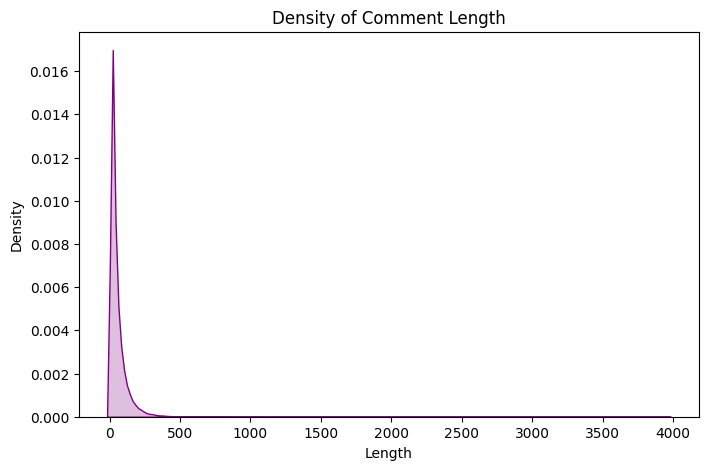

In [6]:
plt.figure(figsize=(8,5))
sns.kdeplot(df['length'], fill=True,color='purple')

plt.title("Density of Comment Length")
plt.xlabel("Length")
plt.show()

In [7]:
normalizer = Normalizer()  # استفاده از parsivar

def clean_text(text):
    # نرمال‌سازی پیشرفته
    text = normalizer.normalize(text)

    # حذف کشیدگی حروف (عاااالی → عالی)
    text = re.sub(r'(.)\1{2,}', r'\1', text)

    # حذف لینک
    text = re.sub(r'http\S+|www\S+', ' ', text)

    # حذف ایموجی و کاراکترهای غیر فارسی
    text = re.sub(r'[^\u0600-\u06FF0-9\s]', ' ', text)

    # حذف فاصله‌های اضافی
    text = re.sub(r'\s+', ' ', text).strip()

    return text

df['clean_body'] = df['body'].astype(str).apply(clean_text)

In [8]:
df=df.drop(["body","product_id"], axis=1)
df.sample(5)

,rate,label,length,clean_body
126382,4.0,1,23,همیشه همینو میخرم راضیم
51992,1.0,0,83,خوش دوخت نیست گشاده وبغل های لباس خوش فرم نیست...
79636,5.0,1,6,بدنیست
19257,5.0,1,17,عالی
49789,5.0,1,36,شکلش متفاوته ولی جنس خوبی داره راضیم


In [9]:
# برچسب‌ها
texts = df['clean_body']
labels = df['label'].values

# تقسیم به آموزش، اعتبارسنجی، تست


اینجا اول کل دیتاست به دو بخش تقسیم
شده:

80٪ → آموزش (X_train_text, y_train)

20٪ → موقت (X_temp_text, y_temp)

سپس آن 20٪ باقی‌مانده نصف شده

10٪ Validation

10٪ Test

In [10]:
X_train_text, X_temp_text, y_train, y_temp = train_test_split(
    texts, labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

X_val_text, X_test_text, y_val, y_test = train_test_split(
    X_temp_text, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

# Vectorizer

In [11]:
# پارامترها

MAX_VOCAB_SIZE = 20000
# یعنی فقط ۲۰ هزار توکن پرتکرار در حافظه ذخیره می شوند

MAX_SEQUENCE_LENGTH = 100
# یعنی خروجی همیشه طول ۱۰۰ خواهد داشت

vectorizer = TextVectorization(
    max_tokens=MAX_VOCAB_SIZE,
    output_mode='int',
    output_sequence_length=MAX_SEQUENCE_LENGTH,
    ngrams=(1, 2)
)

# فقط روی train یاد بگیره
vectorizer.adapt(X_train_text)

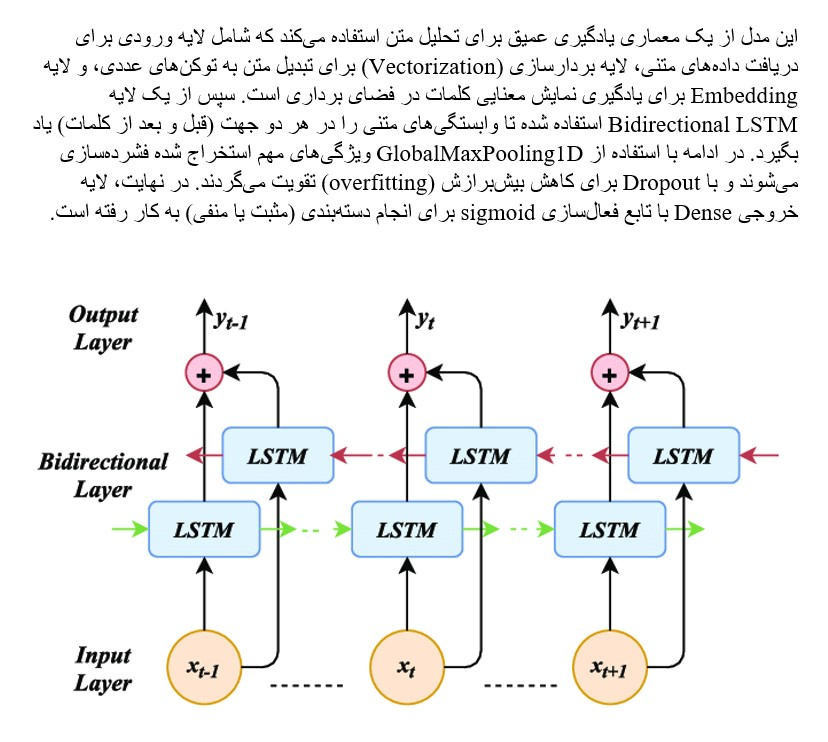

In [14]:
# Input layer for text data
input_layer = layers.Input(shape=(1,), dtype=string)

# Text vectorization
vectorized_text = vectorizer(input_layer)

# Embedding layer
embedded_text = layers.Embedding(
    input_dim=MAX_VOCAB_SIZE,
    output_dim=64
)(vectorized_text)

# Bidirectional LSTM layer
# LSTM Forward + LSTM Backward
bidirectional_lstm = layers.Bidirectional(
    layers.LSTM(
        units=48,
        return_sequences=True,
        dropout=0.4,
        recurrent_dropout=0.3
    )
)(embedded_text)

# GlobalMaxPooling1D
pooled_output = layers.GlobalMaxPooling1D()(bidirectional_lstm)
dropout_1 = layers.Dropout(0.5)(pooled_output)



# Output layer for binary classification
output_layer = layers.Dense(units=1, activation='sigmoid')(dropout_1)

In [15]:
# Create and compile the model
model = Model(inputs=input_layer, outputs=output_layer)

model.compile(
    optimizer=Adam(learning_rate=0.0003),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-6),
    ModelCheckpoint('final_best_lstm_model.keras', monitor='val_loss', save_best_only=True, mode='min', verbose=1)
]

In [17]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ text_vectorization              │ (None, 100)            │             0 │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_2 (Embedding)         │ (None, 100, 64)        │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 100, 96)        │        43,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_2          │ (None, 96)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 96)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            97 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,323,489 (5.05 MB)

 Trainable params: 1,323,489 (5.05 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history = model.fit(
    constant(X_train_text.astype(object), dtype=string),
    y_train,
    validation_data=(constant(X_val_text.astype(object), dtype=string), y_val),
    epochs=30,
    batch_size=512,
    callbacks=callbacks
)

Epoch 1/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 656ms/step - accuracy: 0.6410 - loss: 0.6332
Epoch 1: val_loss improved from None to 0.33776, saving model to /content/drive/MyDrive/Deep_Project/final_best_lstm_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Deep_Project/final_best_lstm_model.keras
235/235 ━━━━━━━━━━━━━━━━━━━━ 171s 683ms/step - accuracy: 0.7338 - loss: 0.5356 - val_accuracy: 0.8702 - val_loss: 0.3378 - learning_rate: 3.0000e-04
Epoch 2/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 645ms/step - accuracy: 0.8703 - loss: 0.3332
Epoch 2: val_loss improved from 0.33776 to 0.27708, saving model to /content/drive/MyDrive/Deep_Project/final_best_lstm_model.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Deep_Project/final_best_lstm_model.keras
235/235 ━━━━━━━━━━━━━━━━━━━━ 156s 663ms/step - accuracy: 0.8773 - loss: 0.3159 - val_accuracy: 0.8926 - val_loss: 0.2771 - learning_rate: 3.0000e-04
Epoch 3/30
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 644ms/step - accuracy: 0

### saving model's history

In [ ]:
# ذخیره در Google Drive
save_path = 'my_model_history.pkl'
with open(save_path, 'wb') as f:
    pickle.dump(history.history, f)

print(f"History saved to: {save_path}")

History saved to: /content/drive/MyDrive/Deep_Project/my_model_history.pkl


In [ ]:
model = load_model('final_best_lstm_model.keras')

In [21]:
loss, acc = model.evaluate(constant(X_test_text.astype(str), dtype=string), y_test)

print("Test Loss:", loss)
print("Test Accuracy:", acc)

469/469 ━━━━━━━━━━━━━━━━━━━━ 68s 141ms/step - accuracy: 0.9081 - loss: 0.2497
Test Loss: 0.2496887594461441
Test Accuracy: 0.908133327960968


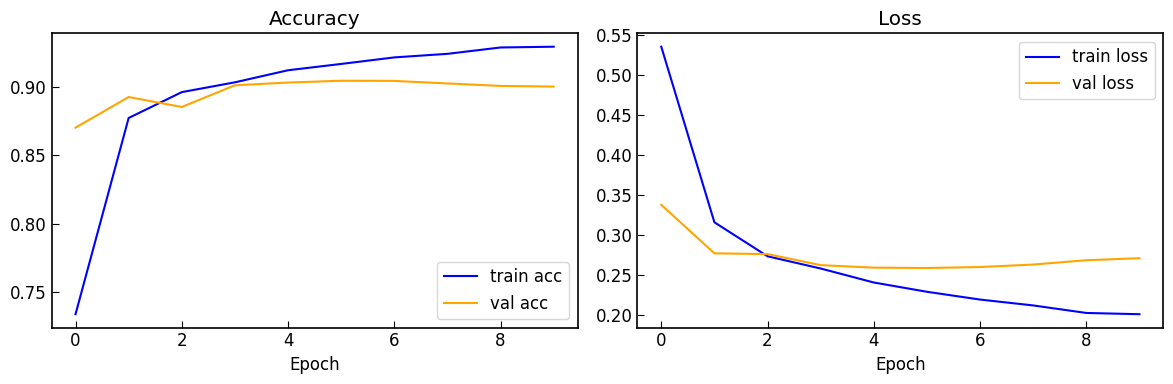

In [ ]:
# 3. بارگذاری فایل pickle
load_path = 'my_model_history.pkl'
with open(load_path, 'rb') as f:
    loaded_history = pickle.load(f)

plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(loaded_history['accuracy'], label='train acc', color='blue')
if 'val_accuracy' in loaded_history:
    plt.plot(loaded_history['val_accuracy'], label='val acc', color='orange')

plt.legend()
plt.title("Accuracy")
plt.xlabel('Epoch')

# Loss
plt.subplot(1, 2, 2)
plt.plot(loaded_history['loss'], label='train loss', color='blue')
if 'val_loss' in loaded_history:
    plt.plot(loaded_history['val_loss'], label='val loss', color='orange')

plt.legend()
plt.title("Loss")
plt.xlabel('Epoch')

plt.tight_layout()
plt.show()

In [22]:
y_pred_prob = model.predict(constant(X_test_text.astype(object), dtype=string))
y_pred = (y_pred_prob > 0.5).astype(int).reshape(-1)

469/469 ━━━━━━━━━━━━━━━━━━━━ 21s 43ms/step


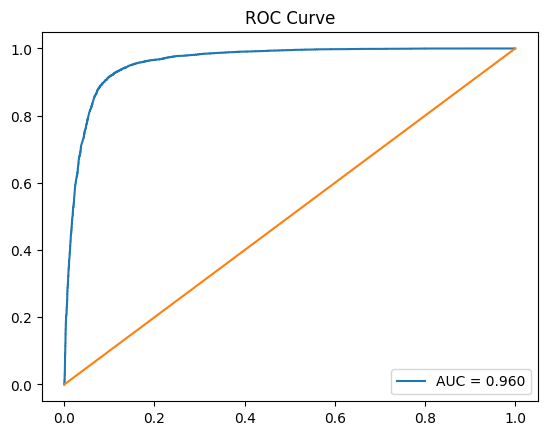

In [23]:
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1])
plt.legend()
plt.title("ROC Curve")
plt.show()

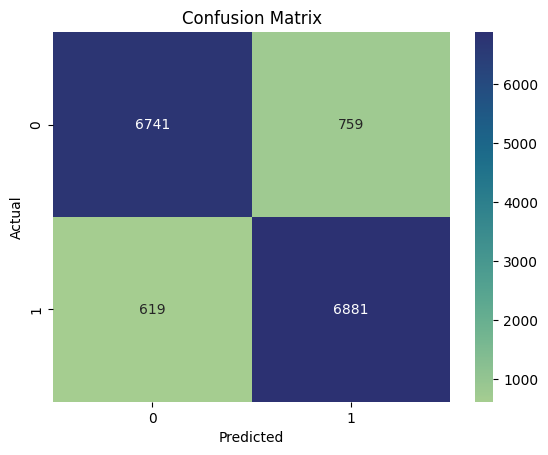

              precision    recall  f1-score   support

           0       0.92      0.90      0.91      7500
           1       0.90      0.92      0.91      7500

    accuracy                           0.91     15000
   macro avg       0.91      0.91      0.91     15000
weighted avg       0.91      0.91      0.91     15000



In [24]:
# ماتریس سردرگمی
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',cmap='crest')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test, y_pred))

## مقایسه توزیع احتمال پیش‌بینی‌های درست و نادرست مدل

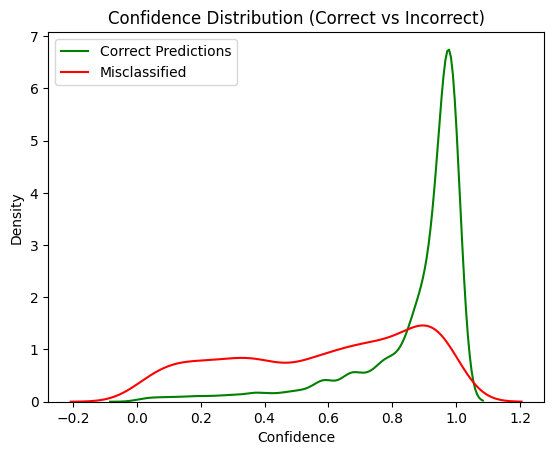

In [25]:
# تبدیل به آرایه 1 بعدی
y_pred_prob = y_pred_prob.reshape(-1)

# confidence = فاصله از مرز 0.5
confidence = np.abs(y_pred_prob - 0.5) * 2

# جدا کردن درست و اشتباه
correct_mask = (y_test == y_pred)
incorrect_mask = (y_test != y_pred)

conf_correct = confidence[correct_mask]
conf_incorrect = confidence[incorrect_mask]

plt.figure()
sns.kdeplot(conf_correct, label="Correct Predictions", color='green')
sns.kdeplot(conf_incorrect, label="Misclassified", color='red')
plt.title("Confidence Distribution (Correct vs Incorrect)")
plt.xlabel("Confidence")
plt.legend()
plt.show()

## تست با داده های ساختگی

In [27]:
# نظرات مثبت
positive_comments = [
    "این محصول واقعا عالیه، کیفیت ساختش فوق‌العاده و نسبت به قیمت خیلی مناسبه",
    "بسیار راضی هستم، سرعت ارسال خوب و بسته‌بندی عالی بود",
    "واقعا ارزش خرید داره، بعد از یک هفته استفاده رضایت کامل دارم",
    "محصول اصل و باکیفیت، ممنون از دیجی‌کالا",
    "عالی عالی عالی، به دوستام هم پیشنهاد دادم",
    "نظر من در مورد این کالا خیلی مثبته، عالیه",
    "رنگش قشنگه",
    "هیچ مشکلی نداره",
    "توی تخفیف خیلی ارزش خرید داره"
]

# نظرات منفی
negative_comments = [
    "کیفیت افتضاح، بعد از دو روز استفاده خراب شد",
    "پشتیبانی خیلی ضعیف، به هیچ عنوان پاسخگو نیستند",
    "با توضیحات تطابق نداره، حیف پولی که دادم",
    "بدترین محصولی که تا حالا خریدم، اصلا پیشنهاد نمیکنم",
    "خیلی دیر رسید و بسته‌بندی هم خراب بود",
    "نظر من در مورد این کالا منفیه، خوب نیست",
    "اصلا خوب نیست",
    "من نمیفهمم چرا وقتی کالا رو ندارید یه چیز بی کیفیت بی ربط میفرستید"

]

def predict_sentiment(text, model):
    """
    پیش‌بینی احساسات یک متن
    """

    text = normalizer.normalize(text)

    # حذف کاراکترهای اضافی
    text = re.sub(r'[^؀-ۿ\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()

    input_tensor = constant([[text]], dtype=string)

    prediction = float(
        model(input_tensor, training=False)[0][0]
    )


    sentiment = "مثبت 😊" if prediction >= 0.5 else "منفی 😞"
    confidence = prediction if prediction >= 0.5 else 1 - prediction

    return {
        "text": text,
        "sentiment": sentiment,
        "score": prediction,
        "confidence": confidence
    }

print("="*50)
print("تست نظرات مثبت:")
print("="*50)
for comment in positive_comments:
    result = predict_sentiment(comment, model)
    print(f"متن: {comment[:50]}...")
    print(f"نتیجه: {result['sentiment']} (احتمال: {result['score']:.3f})")
    print("-"*30)

print("\n" + "="*50)
print("تست نظرات منفی:")
print("="*50)
for comment in negative_comments:
    result = predict_sentiment(comment, model)
    print(f"متن: {comment[:50]}...")
    print(f"نتیجه: {result['sentiment']} (احتمال: {result['score']:.3f})")
    print("-"*30)


تست نظرات مثبت:
متن: این محصول واقعا عالیه، کیفیت ساختش فوق‌العاده و نس...
نتیجه: مثبت 😊 (احتمال: 0.992)
------------------------------
متن: بسیار راضی هستم، سرعت ارسال خوب و بسته‌بندی عالی ب...
نتیجه: مثبت 😊 (احتمال: 0.992)
------------------------------
متن: واقعا ارزش خرید داره، بعد از یک هفته استفاده رضایت...
نتیجه: مثبت 😊 (احتمال: 0.905)
------------------------------
متن: محصول اصل و باکیفیت، ممنون از دیجی‌کالا...
نتیجه: مثبت 😊 (احتمال: 0.967)
------------------------------
متن: عالی عالی عالی، به دوستام هم پیشنهاد دادم...
نتیجه: مثبت 😊 (احتمال: 0.996)
------------------------------
متن: نظر من در مورد این کالا خیلی مثبته، عالیه...
نتیجه: مثبت 😊 (احتمال: 0.913)
------------------------------
متن: رنگش قشنگه...
نتیجه: مثبت 😊 (احتمال: 0.877)
------------------------------
متن: هیچ مشکلی نداره...
نتیجه: مثبت 😊 (احتمال: 0.843)
------------------------------
متن: توی تخفیف خیلی ارزش خرید داره...
نتیجه: مثبت 😊 (احتمال: 0.971)
------------------------------

تست نظرات منفی:
متن: کیفیت ا

## کدام نمونه‌ها بیشترین خطا را برای مدل ایجاد کرده‌اند؟


## فرمول Binary Cross-Entropy:

## L=−[ylog(p)+(1−y)log(1−p)]

In [28]:
# احتمال‌های مدل روی تست
y_test_prob = model.predict(
    constant(X_test_text, dtype=string),
    batch_size=512
)

30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 226ms/step


## اینجا متوجه شدم بیشترین میزان خطای مدل مربوط به داده های اشتباه لیبل گذاری شده است

In [29]:
# گرفتن پیش‌بینی های خام
y_val_prob = model.predict(constant(X_val_text.astype(object), dtype=string), batch_size=512).ravel()
# reshape درست
y_val_flat = np.array(y_val).reshape(-1)
y_val_prob = np.array(y_val_prob).reshape(-1)

# محاسبه BCE دستی
epsilon = 1e-7
per_sample_loss = -(
    y_val_flat * np.log(y_val_prob + epsilon) +
    (1 - y_val_flat) * np.log(1 - y_val_prob + epsilon)
)

# این 50 نمونه با بیشترین loss را پیدا می‌کند
top_k = np.argsort(per_sample_loss)[-50:][::-1]

# چاپ 30 نمونه اول با بیشترین loss
for idx in top_k[:30]:
    print("idx:", idx)
    print("loss:", per_sample_loss[idx])
    print("y_true:", y_val_flat[idx])
    print("prob:", y_val_prob[idx])
    print("text:", X_val_text.iloc[idx])
    print("------")

30/30 ━━━━━━━━━━━━━━━━━━━━ 10s 325ms/step
idx: 652
loss: 6.8285369873046875
y_true: 1
prob: 0.0010823406
text: واقعا متاسفم 10 تاش خراب بودن و کلا سوزن نداشتن و کج بودن
------
idx: 3743
loss: 6.188816547393799
y_true: 1
prob: 0.0020521544
text: مثل من اشتباه نکنید خیلی کوچکه رنگ سیاهش رنگ که میکنم سبزه نارنجیش رنگ نمیده خیلی نوکش ریزه و اصلا نخرید
------
idx: 12718
loss: 6.082103252410889
y_true: 1
prob: 0.0022832695
text: یک بار استفاده کردم ، نخرید اشغاله
------
idx: 1219
loss: 5.944642543792725
y_true: 1
prob: 0.0026197394
text: تصاویرش اصلا کیفیت نداره
------
idx: 12037
loss: 5.693813800811768
y_true: 1
prob: 0.0033666282
text: من پیشنهاد نمیکنم چون برای من ی رنگ دیگه اوردن جنس مهکم و عالیی نداره ولی باز میشه استفاده کرد
------
idx: 7954
loss: 5.6315202713012695
y_true: 1
prob: 0.0035830236
text: با اینکه رنگ مشکیه ولی خیلی کم رنگ پس میده بعد از اولین شست و شو هم که دیگه اصلا رنگ پس نمیده
------
idx: 9890
loss: 5.623416423797607
y_true: 1
prob: 0.003612179
text: بد نیست سایزش درست 

## پیدا کردن نمونه‌های مشکوک در دیتاست

In [30]:
X_all = np.concatenate([X_train_text, X_val_text, X_test_text])
y_all = np.concatenate([y_train, y_val, y_test])

In [40]:
y_all_prob = model.predict(X_all).flatten()
y_all_flat = y_all.flatten()

4688/4688 ━━━━━━━━━━━━━━━━━━━━ 591s 126ms/step


### نمونه‌های مشکوک  در اینجا آن‌هایی در نظر گرفته شده‌اند که مدل با اطمینان بسیار بالا (بیش از 0.98 یا کمتر از 0.02) پیش‌بینی متفاوتی نسبت به برچسب واقعی انجام داده است. با بررسی مثال های آن به اشتباه بودن برچسب های اولیه پی می بریم

In [48]:
overconf_idx = np.where(
    ((y_all_flat == 1) & (y_all_prob < 0.02)) |
    ((y_all_flat == 0) & (y_all_prob > 0.98))
)[0]

print("Total overconfident suspicious samples:", len(overconf_idx))
print("Percentage removed:", len(overconf_idx) / len(y_all_flat) * 100, "%")

Total overconfident suspicious samples: 689
Percentage removed: 0.4593333333333333 %


### تعداد نمونه های مشکوک فقط 0.5 درصد کل داده هاست و حذف آنها تغییر موثری ایجاد نمی کند
(برای اطمینان از این موضوع در نوت بوک دیگری، این داده ها را حذف کردم و نتیجه تقریبا یکسان بود)

In [49]:
# چاپ ده مورد از نمونه های مشکوک
for idx in overconf_idx[:10]:
    print(y_all_flat[idx])
    print(y_all_prob[idx])
    print(X_all[idx])
    print("-----")

0
0.99209654
نسبت به قیمت عالیه و جنس خوبی داره
-----
1
0.012980658
گشاد و بد رنگ
-----
0
0.99209714
عالی و نرم و راحت
-----
1
0.014503941
جنسش خوب نبود
-----
1
0.0028200692
اولش که اومد اصلا عقربه ها تکون نمیخوره به شدت ناامید شدم بعد5 دیگه شروع کرد به کار کردن یه جایی عقربه ثانیه تیک داره یعنی عقربه ثانیه میره عقب یه دونه دوباره میره جلو دوباره میره عقب دوباره میره جلو و انگار توی این تیکا عقربه ی دقیقه هم بالا پایین میشه ولی در کل برمیگرده به همون ساعت قبلی و همون درسته یعنی ساعت درسته زیاد این تیکش چیز نیس که تنظیم ساعت رو یه دقه بالا پایین کنه
-----
1
0.007381266
کتاب من از صفحه 49 تا 65 رو نداره کد سفارش رو هم دور انداختم و امکان پس دادن نیست متاسفانه
-----
0
0.98343766
خوب و خوش دست
-----
0
0.993473
عالی خیلی خوب بود توصیه میکنم
-----
1
0.019178072
همسرم خریده بود ، جنسش آشغال بهش می چسبه
-----
0
0.98977965
بسیار زیبا و با کیفیت بود
-----


## آیا طول متن با میزان خطای مدل رابطه‌ای دارد یا نه

In [31]:
lengths = [len(t.split()) for t in X_val_text.ravel()]
length_loss_df = pd.DataFrame({'text': X_val_text.ravel(), 'loss': per_sample_loss, 'len': lengths, 'y': y_val})
length_loss_df.groupby(pd.cut(length_loss_df['len'], bins=[0,2,5,10,20,100]))['loss'].mean()

/tmp/ipykernel_2135/1354365979.py:1: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  lengths = [len(t.split()) for t in X_val_text.ravel()]
/tmp/ipykernel_2135/1354365979.py:2: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  length_loss_df = pd.DataFrame({'text': X_val_text.ravel(), 'loss': per_sample_loss, 'len': lengths, 'y': y_val})
/tmp/ipykernel_2135/1354365979.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  length_loss_df.groupby(pd.cut(length_loss_df['len'], bins=[0,2,5,10,20,100]))['loss'].mean()


,loss
len,
"(0, 2]",0.342114
"(2, 5]",0.244026
"(5, 10]",0.250455
"(10, 20]",0.247757
"(20, 100]",0.229016


### به نظر می رسد مدل با کامنت های یک تا دو کلمه ای کمی مشکل دارد
### اما تعدادشان در دیتاست بسیار ناچیز است، پس کاری به آنها ندارم

In [32]:
df.groupby(
    pd.cut(df['length'], bins=[0,2,5,10,20,100])
).size()

/tmp/ipykernel_2135/3645348337.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(


,0
length,
"(0, 2]",9
"(2, 5]",6972
"(5, 10]",8609
"(10, 20]",32650
"(20, 100]",80986


# مقایسه با مدل های سبک تر

In [33]:
# تقسیم داده برای مدل های سبکتر بدون validation
X_train_new, X_test_new, y_train_new, y_test_new = train_test_split(
    X_all,
    y_all,
    test_size=0.2,          # 20% برای تست
    random_state=42,
    stratify=y_all)          # حفظ نسبت کلاس‌ها

## Logistic Regression + TF-IDF

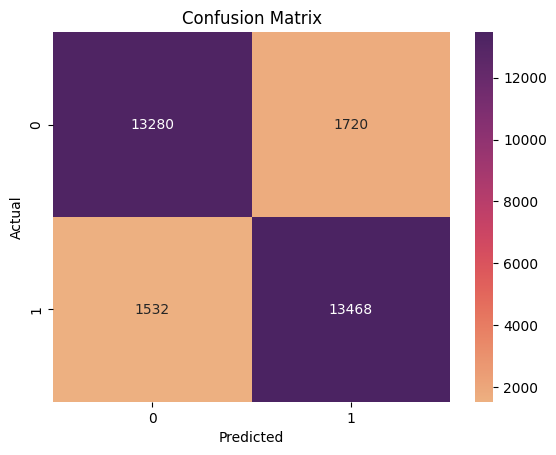

              precision    recall  f1-score   support

           0       0.90      0.89      0.89     15000
           1       0.89      0.90      0.89     15000

    accuracy                           0.89     30000
   macro avg       0.89      0.89      0.89     30000
weighted avg       0.89      0.89      0.89     30000



In [37]:
tfidf = TfidfVectorizer(
    max_features=20000
)

X_train_tfidf = tfidf.fit_transform(X_train_new)
X_test_tfidf = tfidf.transform(X_test_new)

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_tfidf, y_train_new)

y_pred_lr = lr.predict(X_test_tfidf)

cm = confusion_matrix(y_test_new, y_pred_lr)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',cmap='flare')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test_new, y_pred_lr))

## Multinomial Naive Bayes

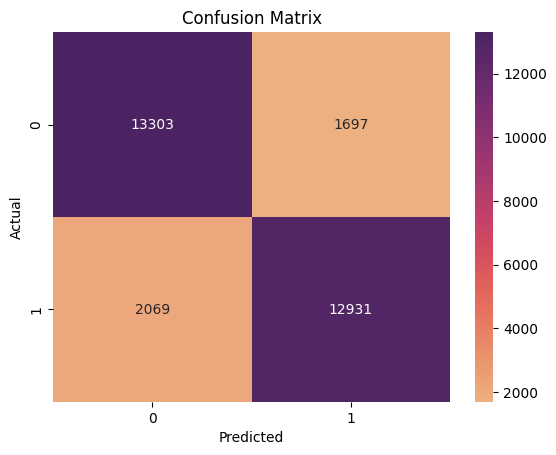

              precision    recall  f1-score   support

           0       0.87      0.89      0.88     15000
           1       0.88      0.86      0.87     15000

    accuracy                           0.87     30000
   macro avg       0.87      0.87      0.87     30000
weighted avg       0.87      0.87      0.87     30000



In [35]:
nb = MultinomialNB()

nb.fit(X_train_tfidf, y_train_new)

y_pred_nb = nb.predict(X_test_tfidf)

cm = confusion_matrix(y_test_new, y_pred_nb)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',cmap='flare')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

print(classification_report(y_test_new, y_pred_nb))

# Accuracy

In [38]:
# Naive Bayes
nb_acc = accuracy_score(y_test_new, y_pred_nb)

# Logistic Regression
lr_acc = accuracy_score(y_test_new, y_pred_lr)

# LSTM
lstm_acc = accuracy_score(y_test, y_pred)

print(f"Naive Bayes Accuracy: {nb_acc:.4f}")
print(f"Logistic Regression Accuracy: {lr_acc:.4f}")
print(f"LSTM Accuracy: {lstm_acc:.4f}")

Naive Bayes Accuracy: 0.8745
Logistic Regression Accuracy: 0.8916
LSTM Accuracy: 0.9081


# نمودار مقایسه

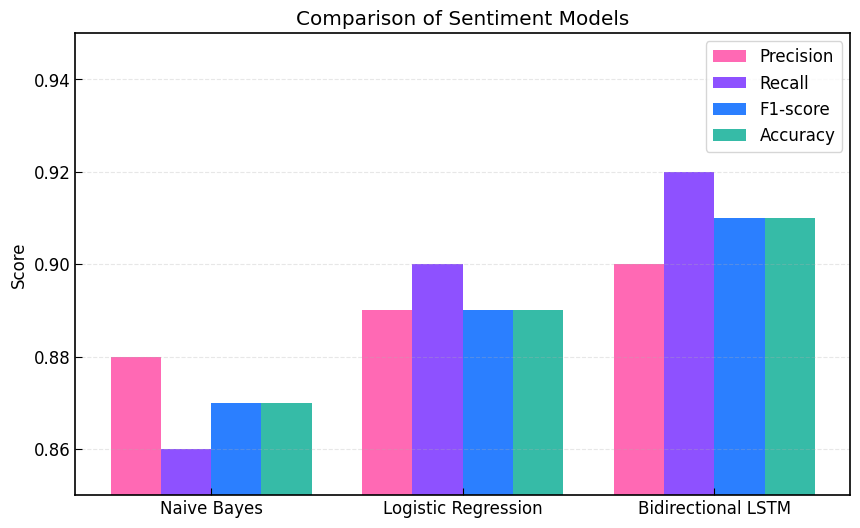

In [47]:
models = ["Naive Bayes", "Logistic Regression", "Bidirectional LSTM"]

precision = [0.88, 0.89, 0.90]
recall    = [0.86, 0.90, 0.92]
f1_score  = [0.87, 0.89, 0.91]
accuracy  = [0.87, 0.89, 0.91]

x = np.arange(len(models))
width = 0.2

plt.figure(figsize=(10,6))

plt.bar(x - 1.5*width, precision, width, label="Precision", color="hotpink")
plt.bar(x - 0.5*width, recall, width, label="Recall", color="#8E51FF")
plt.bar(x + 0.5*width, f1_score, width, label="F1-score", color="#2B7FFF")
plt.bar(x + 1.5*width, accuracy, width, label="Accuracy", color="#36BBA7")

plt.xticks(x, models)
plt.ylim(0.85, 0.95)

plt.title("Comparison of Sentiment Models")
plt.ylabel("Score")
plt.legend()

plt.grid(axis="y", linestyle="--", alpha=0.3)

plt.show()

## مدل ال اس تی ام من توانسته الگوهای ترتیبی و وابستگی بین کلمات را بهتر از  مدل‌های کلاسیک یادگیری ماشین یاد بگیرد